# Positional Embeddings in PyTorch

[link](https://ut.philkr.net/deeplearning/transformers/positional_embeddings_in_pytorch/)

In [1]:
import torch
import torch.nn as nn
import numpy as np
from PIL import Image
from models.deep_learning.architectures import MLP
from models.deep_learning.components.embeddings.visualization import plot_embeddingdims, plot_embedding
from models.deep_learning.components import SinusoidalPositionalEncoding
device = torch.device("mps")

## Sinusoidal positional encoding

In [2]:
fourier_posenc = SinusoidalPositionalEncoding(embed_dim=24).to(device)
emb = fourier_posenc(spatial_dimensions=(130,))
emb.shape

torch.Size([130, 24])

## Embedding Visualization (per dimension)

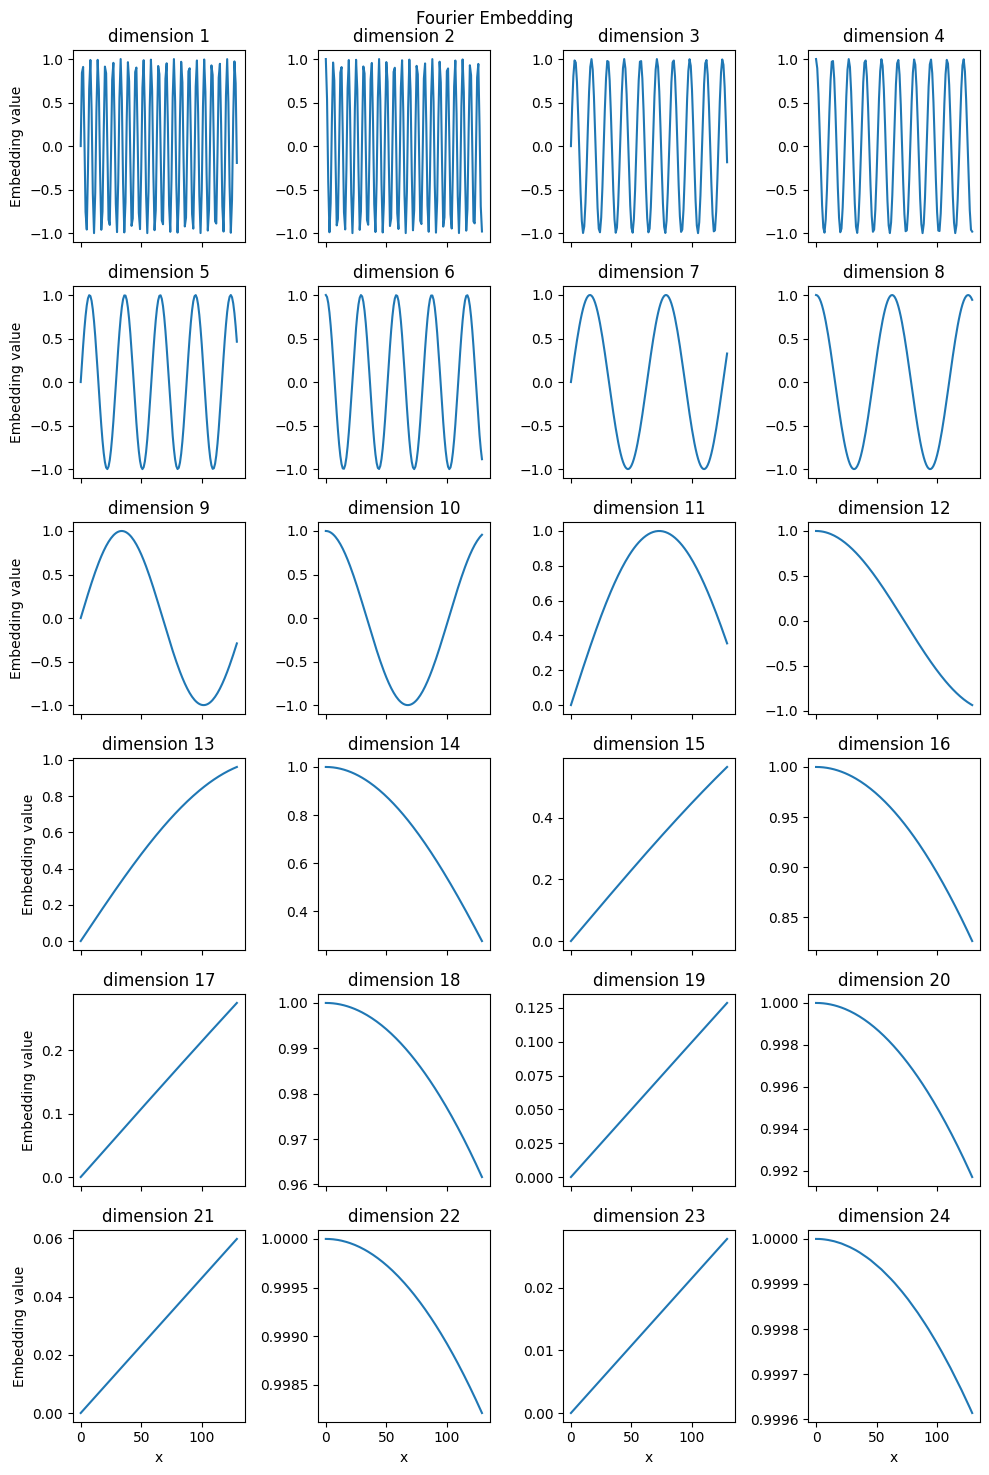

In [3]:
position = SinusoidalPositionalEncoding.make_coords((130,), torch.device("cpu"))

plot_embeddingdims(position, emb.detach().cpu(), title="Fourier Embedding")

## Embedding Visualization (heat map)

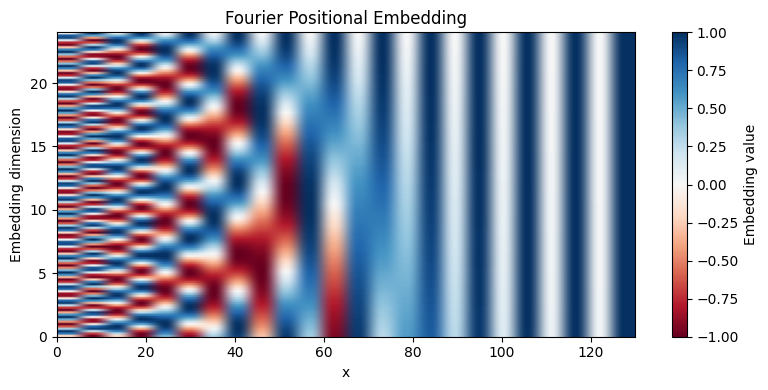

In [4]:
plot_embedding(emb.detach().cpu(), "Fourier Positional Embedding")

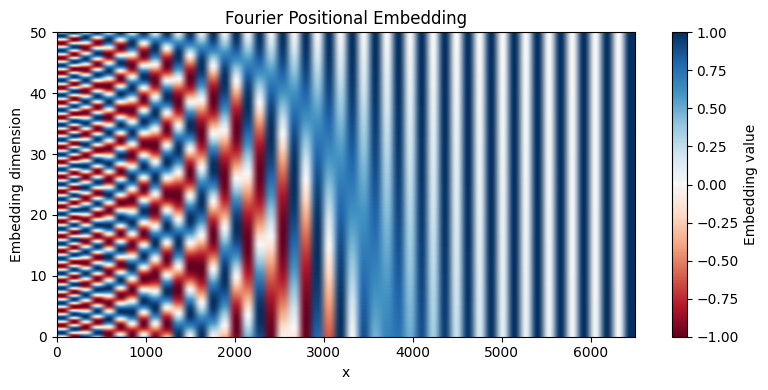

In [7]:
fourier_posenc = SinusoidalPositionalEncoding(embed_dim=50).to(device)
emb = fourier_posenc(spatial_dimensions=(130,),sampling_factor=50)
plot_embedding(emb.detach().cpu(), "Fourier Positional Embedding")

## Test

Lets learn a figure map (from spatial position to pixel colors)

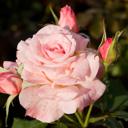

In [8]:
im = Image.open('rose_crop.jpeg').convert('RGB')
im_small = im.resize((128, 128))
im_small

## Learn without positional encoding

In [9]:
rosenet = MLP(input_dim=2,output_dim=3,hidden_dims=[256,128,64],activation_cls=nn.ReLU)    

In [10]:
rose_tensor = torch.as_tensor(np.array(im_small),dtype=torch.float32) / 255. - 0.5
xs = torch.linspace(-1, 1, im_small.size[1])
ys = torch.linspace(-1, 1, im_small.size[0])  

norm_position = torch.stack(
    torch.meshgrid(ys, xs, indexing="ij"),  
    dim=-1,
)
norm_position.shape

torch.Size([128, 128, 2])

## Training

In [11]:
rose_tensor = rose_tensor.to(device)
norm_position = norm_position.to(device)

net = rosenet.to(device)
optim = torch.optim.Adam(net.parameters(), lr=1e-3)

for it in range(5000):
    optim.zero_grad()
    loss = abs(net(norm_position)- rose_tensor).mean()
    loss.backward()
    optim.step()
    if it % 100 == 0:
        print(f"Iteration {it}, loss: {loss.item():.6f}")

Iteration 0, loss: 0.340681
Iteration 100, loss: 0.107132
Iteration 200, loss: 0.088906
Iteration 300, loss: 0.084645
Iteration 400, loss: 0.075277
Iteration 500, loss: 0.071912
Iteration 600, loss: 0.069412
Iteration 700, loss: 0.067443
Iteration 800, loss: 0.065568
Iteration 900, loss: 0.063545
Iteration 1000, loss: 0.064082
Iteration 1100, loss: 0.061020
Iteration 1200, loss: 0.061061
Iteration 1300, loss: 0.060139
Iteration 1400, loss: 0.058157
Iteration 1500, loss: 0.058511
Iteration 1600, loss: 0.058972
Iteration 1700, loss: 0.055983
Iteration 1800, loss: 0.055478
Iteration 1900, loss: 0.055732
Iteration 2000, loss: 0.055504
Iteration 2100, loss: 0.055219
Iteration 2200, loss: 0.056496
Iteration 2300, loss: 0.052763
Iteration 2400, loss: 0.052748
Iteration 2500, loss: 0.052176
Iteration 2600, loss: 0.051728
Iteration 2700, loss: 0.052120
Iteration 2800, loss: 0.051222
Iteration 2900, loss: 0.051167
Iteration 3000, loss: 0.051871
Iteration 3100, loss: 0.050164
Iteration 3200, loss

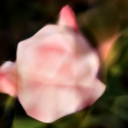

In [12]:
Image.fromarray(((net(norm_position)+0.5).clamp(0,1).cpu().detach().numpy()*255).astype(np.uint8))

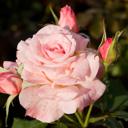

In [13]:
im_small

## Training with Sinusoidal positional encoding

In [14]:
emb_dim = 16
fourier_posenc = SinusoidalPositionalEncoding(embed_dim=emb_dim, ndim=2).to(device)
rosenet = MLP(input_dim=emb_dim,output_dim=3,hidden_dims=[256,128,64],activation_cls=nn.ReLU).to(device)   
fourier_posenc(spatial_dimensions=im_small.size).shape

torch.Size([128, 128, 16])

In [15]:
rose_tensor = rose_tensor.to(device)
optim = torch.optim.Adam(rosenet.parameters(), lr=1e-3)

for it in range(5000):
    optim.zero_grad()
    loss = abs(rosenet(fourier_posenc(im_small.size)) - rose_tensor).mean()
    loss.backward()
    optim.step()
    if it % 100 == 0:
        print(f"Iteration {it}, loss: {loss.item():.6f}")

Iteration 0, loss: 0.314135
Iteration 100, loss: 0.096923
Iteration 200, loss: 0.074622
Iteration 300, loss: 0.065792
Iteration 400, loss: 0.061963
Iteration 500, loss: 0.056245
Iteration 600, loss: 0.052345
Iteration 700, loss: 0.051168
Iteration 800, loss: 0.049982
Iteration 900, loss: 0.046190
Iteration 1000, loss: 0.044780
Iteration 1100, loss: 0.043378
Iteration 1200, loss: 0.042700
Iteration 1300, loss: 0.041014
Iteration 1400, loss: 0.039782
Iteration 1500, loss: 0.039448
Iteration 1600, loss: 0.041765
Iteration 1700, loss: 0.038603
Iteration 1800, loss: 0.037354
Iteration 1900, loss: 0.040901
Iteration 2000, loss: 0.038098
Iteration 2100, loss: 0.038275
Iteration 2200, loss: 0.035272
Iteration 2300, loss: 0.034324
Iteration 2400, loss: 0.034190
Iteration 2500, loss: 0.032569
Iteration 2600, loss: 0.032338
Iteration 2700, loss: 0.032157
Iteration 2800, loss: 0.033747
Iteration 2900, loss: 0.030884
Iteration 3000, loss: 0.031498
Iteration 3100, loss: 0.031282
Iteration 3200, loss

In [22]:
img_gen = rosenet(fourier_posenc(im_small.size)).detach().cpu()
img_gen.shape

torch.Size([128, 128, 3])

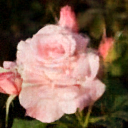

In [23]:
Image.fromarray(((img_gen+0.5).clamp(0,1).cpu().detach().numpy()*255).astype(np.uint8))

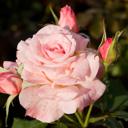

In [24]:
im_small

## Generalization (bigger image)

In [25]:
img_gen = rosenet(fourier_posenc(im_small.size, sampling_factor=8))
img_gen.shape

torch.Size([1024, 1024, 3])

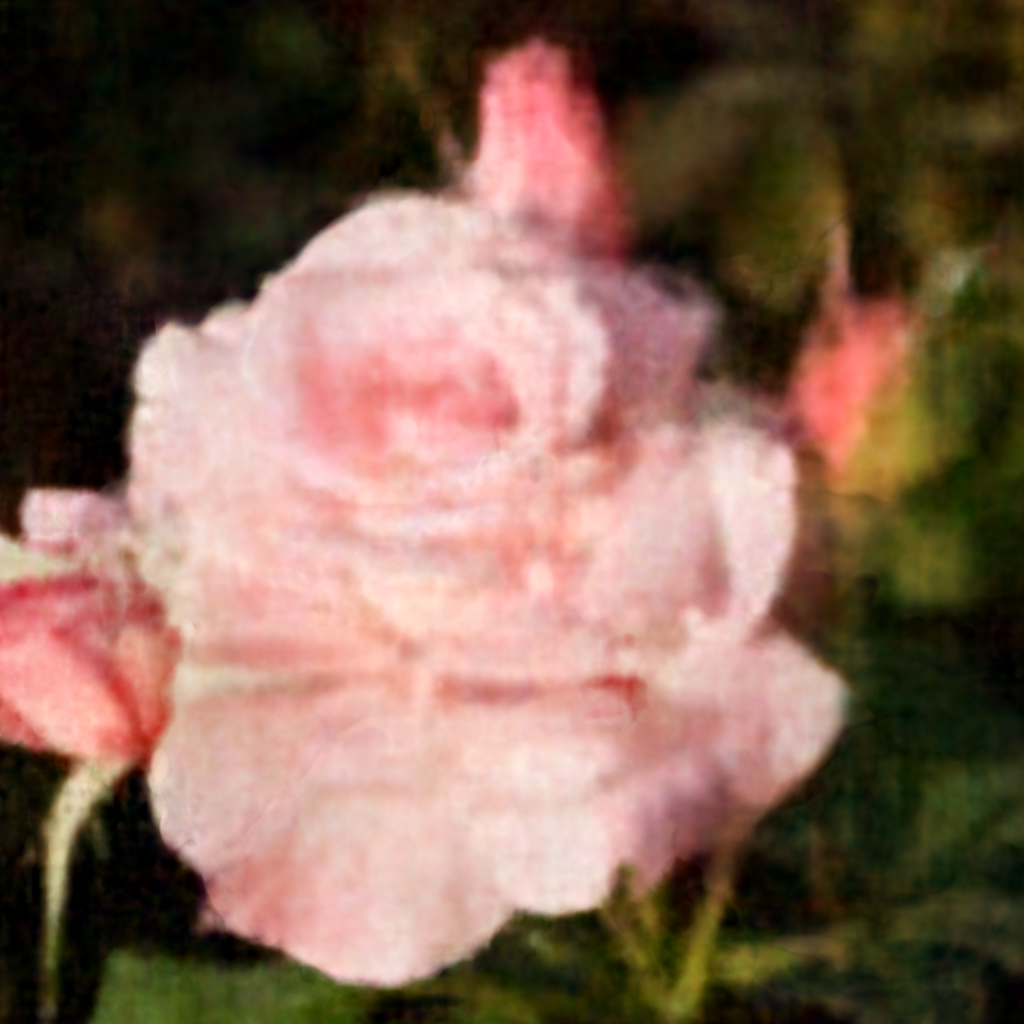

In [26]:
Image.fromarray(((img_gen+0.5).clamp(0,1).cpu().detach().numpy()*255).astype(np.uint8))

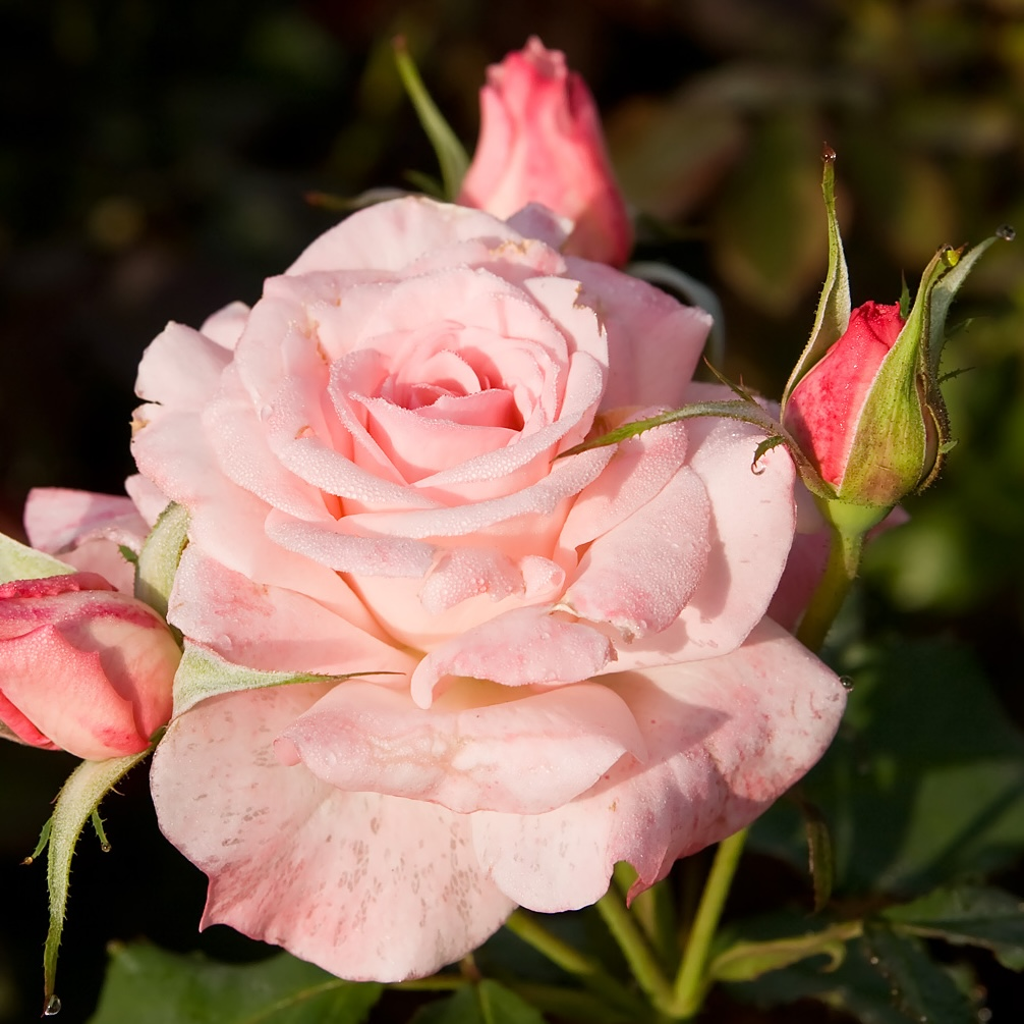

In [27]:
im.resize((1024, 1024))